In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import sys

In [2]:
FILE_PATH   = r"D:\XAI\Research Papers\Eyes Research Ppaer\Eye Dataset\archive (5)\ODIR-5K\ODIR-5K\data.xlsx"      # path to your CSV or Excel file
TARGET_COL  = None                     # For single-label: set column name e.g. "label"
                                       # For multi-label: set to None (auto-detected)
MULTI_LABEL_COLS = ['N','D','G','C','A','H','M','O']  # multi-label binary columns
                                       # set to [] to auto-detect binary 0/1 columns
LABEL_NAMES = {                        # friendly names for labels (optional)
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}
SAVE_PLOT   = True                     # save plot to disk?
PLOT_PATH   = "class_balance_report.png"

In [3]:
# ── DARK THEME ────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#1a1d2e",
    "axes.edgecolor":    "#2d3148",
    "axes.labelcolor":   "#aaaaaa",
    "axes.titlecolor":   "white",
    "xtick.color":       "#cccccc",
    "ytick.color":       "#cccccc",
    "grid.color":        "#2d3148",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "text.color":        "white",
    "legend.facecolor":  "#1a1d2e",
    "legend.edgecolor":  "#2d3148",
})

PALETTE = [
    "#4ade80","#22d3ee","#a78bfa","#f472b6",
    "#fb923c","#f87171","#facc15","#94a3b8",
    "#38bdf8","#86efac","#fda4af","#c084fc",
]

def color_by_ratio(ratio):
    if ratio < 2:   return "#4ade80"   # green  – balanced
    if ratio < 5:   return "#facc15"   # yellow – mild
    return              "#f87171"      # red    – severe

In [10]:
def load_data(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    elif ext == ".csv":
        df = pd.read_csv(path)
    else:
        sys.exit(f"Unsupported file type: {ext}")
    print(f"\n{'─'*55}")
    print(f"  ✅ Loaded: {path}")
    print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
    print(f"{'─'*55}")
    return df
df   = load_data(FILE_PATH)


───────────────────────────────────────────────────────
  ✅ Loaded: D:\XAI\Research Papers\Eyes Research Ppaer\Eye Dataset\archive (5)\ODIR-5K\ODIR-5K\data.xlsx
  Rows: 3,500  |  Columns: 15
───────────────────────────────────────────────────────


In [11]:
df.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [12]:
df.isnull().sum()

ID                           0
Patient Age                  0
Patient Sex                  0
Left-Fundus                  0
Right-Fundus                 0
Left-Diagnostic Keywords     0
Right-Diagnostic Keywords    0
N                            0
D                            0
G                            0
C                            0
A                            0
H                            0
M                            0
O                            0
dtype: int64

In [14]:
def detect_task(df, target_col, multilabel_cols):
    # Multi-label: explicit cols given
    if multilabel_cols:
        missing = [c for c in multilabel_cols if c not in df.columns]
        if missing:
            sys.exit(f"Columns not found in dataset: {missing}")
        return "multi", multilabel_cols

    # Single-label: explicit target given
    if target_col:
        if target_col not in df.columns:
            sys.exit(f"Column '{target_col}' not found.")
        return "single", target_col

    # Auto-detect: look for binary 0/1 columns that could be labels
    binary_cols = [
        c for c in df.columns
        if df[c].dropna().isin([0, 1]).all() and df[c].nunique() == 2
    ]
    if len(binary_cols) > 1:
        print(f"\n  ℹ️  Auto-detected multi-label columns: {binary_cols}")
        return "multi", binary_cols

    # Fall back: last non-numeric column or last column
    candidate = df.select_dtypes(include="object").columns
    col = candidate[-1] if len(candidate) else df.columns[-1]
    print(f"\n  ℹ️  Auto-detected single-label column: '{col}'")
    return "single", col
task, target = detect_task(df, TARGET_COL, MULTI_LABEL_COLS)

In [15]:
def compute_stats_single(df, col):
    series   = df[col].dropna()
    total    = len(series)
    counts   = series.value_counts().sort_values(ascending=False)
    pcts     = (counts / total * 100).round(2)
    max_cnt  = counts.max()
    min_cnt  = counts.min()
    ir       = max_cnt / min_cnt

    stats = pd.DataFrame({
        "Class":      counts.index,
        "Count":      counts.values,
        "Percentage": pcts.values,
        "Ratio (max/class)": [round(max_cnt / c, 2) for c in counts.values],
    })
    return stats, total, ir, max_cnt, min_cnt

def compute_stats_multi(df, cols, label_names):
    total   = len(df)
    records = []
    for col in cols:
        cnt  = df[col].sum()
        name = label_names.get(col, col)
        records.append({
            "Column":     col,
            "Class":      name,
            "Count":      int(cnt),
            "Percentage": round(cnt / total * 100, 2),
        })
    stats   = pd.DataFrame(records).sort_values("Count", ascending=False)
    max_cnt = stats["Count"].max()
    min_cnt = stats["Count"].min()
    ir      = max_cnt / min_cnt
    stats["Ratio (max/class)"] = (max_cnt / stats["Count"]).round(2)
    return stats.reset_index(drop=True), total, ir, max_cnt, min_cnt


In [16]:
def print_report(stats, total, ir, task, max_cnt, min_cnt):
    print(f"\n{'═'*55}")
    print(f"  📊  CLASS DISTRIBUTION REPORT")
    print(f"{'═'*55}")
    print(f"  Task type : {'Multi-label' if task=='multi' else 'Single-label'}")
    print(f"  Total rows: {total:,}")
    print(f"  Classes   : {len(stats)}")
    print(f"\n{stats.to_string(index=False)}")

    print(f"\n{'─'*55}")
    print(f"  Max class count : {max_cnt:,}")
    print(f"  Min class count : {min_cnt:,}")
    print(f"  Imbalance Ratio : {ir:.2f}x")

    if ir < 1.5:
        verdict = "✅  BALANCED"
        detail  = "Classes are nearly equal. No special handling needed."
    elif ir < 3:
        verdict = "⚠️  MILDLY IMBALANCED"
        detail  = "Slight imbalance. Consider class weights or mild oversampling."
    elif ir < 10:
        verdict = "🔶  MODERATELY IMBALANCED"
        detail  = "Noticeable imbalance. Use SMOTE, class weights, or threshold tuning."
    else:
        verdict = "🔴  SEVERELY IMBALANCED"
        detail  = "Major imbalance. Use SMOTE/MLSMOTE, focal loss, or resampling."

    print(f"\n  Conclusion : {verdict}")
    print(f"  Advice     : {detail}")
    print(f"{'═'*55}\n")

    print("  📌 Recommended Techniques:")
    techniques = [
        ("Oversampling (SMOTE / MLSMOTE)",
         "pip install imbalanced-learn  →  from imblearn.over_sampling import SMOTE"),
        ("Class Weights",
         "sklearn: class_weight='balanced'  |  Keras: class_weight={...}"),
        ("Threshold Tuning",
         "Tune per-class decision threshold after training to boost minority recall"),
        ("Focal Loss",
         "Penalises easy majority samples, focuses training on hard minority ones"),
        ("Undersampling",
         "from imblearn.under_sampling import RandomUnderSampler"),
    ]
    for i, (name, tip) in enumerate(techniques, 1):
        print(f"  {i}. {name}")
        print(f"     → {tip}")
    print()


In [17]:
def plot_single(stats, total, ir):
    classes  = stats["Class"].astype(str)
    counts   = stats["Count"]
    pcts     = stats["Percentage"]
    ratios   = stats["Ratio (max/class)"]
    bar_cols = [color_by_ratio(r) for r in ratios]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Class Balance Analysis", fontsize=16, fontweight="bold", y=1.02)

    # Bar chart
    ax = axes[0]
    bars = ax.bar(classes, counts, color=bar_cols, edgecolor="#2d3148", linewidth=0.8)
    ax.set_title("Class Count Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f"{c:,}", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="white")

    # Pie chart
    ax = axes[1]
    pie_cols = PALETTE[:len(classes)]
    wedges, _, autotexts = ax.pie(
        counts, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
        colors=pie_cols, startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5)
    )
    for at in autotexts:
        at.set_color("white"); at.set_fontsize(8)
    ax.legend(classes, loc="lower center", bbox_to_anchor=(0.5, -0.12),
              ncol=min(4, len(classes)), fontsize=8, framealpha=0)
    ax.set_title("Percentage Distribution", fontsize=13, fontweight="bold")

    # Imbalance ratio
    ax = axes[2]
    ratio_cols = [color_by_ratio(r) for r in ratios]
    hbars = ax.barh(classes[::-1], ratios[::-1], color=ratio_cols[::-1], edgecolor="#2d3148")
    ax.axvline(1, color="#4ade80", linestyle="--", linewidth=1.2, label="Balanced (1x)")
    ax.axvline(5, color="#facc15", linestyle="--", linewidth=1.2, label="Mild (5x)")
    ax.axvline(10, color="#f87171", linestyle="--", linewidth=1.2, label="Severe (10x)")
    ax.set_title("Imbalance Ratio (max ÷ class)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Ratio"); ax.xaxis.grid(True); ax.set_axisbelow(True)
    for bar, r in zip(hbars, ratios[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{r:.2f}x", va="center", fontsize=8.5, fontweight="bold", color="white")
    p1 = mpatches.Patch(color="#4ade80", label="Balanced (<2x)")
    p2 = mpatches.Patch(color="#facc15", label="Mild (2–5x)")
    p3 = mpatches.Patch(color="#f87171", label="Severe (>5x)")
    ax.legend(handles=[p1, p2, p3], fontsize=7.5, framealpha=0.3, loc="lower right")

    _add_legend_and_save()

In [18]:
def plot_multi(stats, total, ir):
    classes  = stats["Class"]
    counts   = stats["Count"]
    pcts     = stats["Percentage"]
    ratios   = stats["Ratio (max/class)"]

    fig = plt.figure(figsize=(20, 10))
    fig.suptitle("Multi-Label Class Balance Analysis", fontsize=16, fontweight="bold", y=1.01)
    gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

    # ── Top-left: Count bar
    ax1 = fig.add_subplot(gs[0, 0])
    bar_cols = [color_by_ratio(r) for r in ratios]
    bars = ax1.bar(classes, counts, color=bar_cols, edgecolor="#2d3148", linewidth=0.8)
    ax1.set_title("Class Count Distribution", fontweight="bold")
    ax1.set_ylabel("Count"); ax1.yaxis.grid(True); ax1.set_axisbelow(True)
    ax1.tick_params(axis="x", rotation=30)
    for bar, c in zip(bars, counts):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts)*0.01,
                 f"{c:,}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="white")

    # ── Top-middle: Percentage bar
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(classes, pcts, color=bar_cols, edgecolor="#2d3148", linewidth=0.8)
    ax2.axhline(100/len(classes), color="white", linestyle="--", linewidth=1.2,
                label=f"Ideal ({100/len(classes):.1f}%)")
    ax2.set_title("Percentage Distribution", fontweight="bold")
    ax2.set_ylabel("Percentage (%)"); ax2.yaxis.grid(True); ax2.set_axisbelow(True)
    ax2.tick_params(axis="x", rotation=30)
    ax2.legend(fontsize=8, framealpha=0.3)

    # ── Top-right: Pie
    ax3 = fig.add_subplot(gs[0, 2])
    pie_cols = PALETTE[:len(classes)]
    _, _, autotexts = ax3.pie(
        counts, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
        colors=pie_cols, startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5)
    )
    for at in autotexts:
        at.set_color("white"); at.set_fontsize(8)
    ax3.legend(classes, loc="lower center", bbox_to_anchor=(0.5,-0.12),
               ncol=4, fontsize=7.5, framealpha=0)
    ax3.set_title("Share of Dataset", fontweight="bold")

    # ── Bottom-left: Imbalance ratio
    ax4 = fig.add_subplot(gs[1, 0])
    ratio_cols = [color_by_ratio(r) for r in ratios]
    hbars = ax4.barh(classes[::-1], ratios[::-1], color=ratio_cols[::-1], edgecolor="#2d3148")
    ax4.axvline(1,  color="#4ade80", linestyle="--", linewidth=1.2)
    ax4.axvline(5,  color="#facc15", linestyle="--", linewidth=1.2)
    ax4.axvline(10, color="#f87171", linestyle="--", linewidth=1.2)
    ax4.set_title("Imbalance Ratio", fontweight="bold")
    ax4.set_xlabel("Ratio (max ÷ class)"); ax4.xaxis.grid(True); ax4.set_axisbelow(True)
    for bar, r in zip(hbars, ratios[::-1]):
        ax4.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                 f"{r:.1f}x", va="center", fontsize=8, fontweight="bold", color="white")

    # ── Bottom-middle: Label co-occurrence heatmap
    ax5 = fig.add_subplot(gs[1, 1])
    label_df = pd.read_excel(FILE_PATH) if FILE_PATH.endswith(("xlsx","xls")) else pd.read_csv(FILE_PATH)
    raw_cols = stats["Column"].tolist() if "Column" in stats.columns else stats["Class"].tolist()
    if all(c in label_df.columns for c in raw_cols):
        co_matrix = label_df[raw_cols].T.dot(label_df[raw_cols])
        co_arr = co_matrix.values.copy()
        np.fill_diagonal(co_arr, 0)
        co_matrix = pd.DataFrame(co_arr, index=co_matrix.index, columns=co_matrix.columns)
        short = [c[:4] for c in raw_cols]
        co_matrix.index = short; co_matrix.columns = short
        sns.heatmap(co_matrix, ax=ax5, cmap="YlOrRd", annot=True, fmt="d",
                    linewidths=0.5, linecolor="#0f1117",
                    cbar_kws={"shrink": 0.7})
    ax5.set_title("Label Co-occurrence", fontweight="bold")
    ax5.tick_params(colors="#cccccc")

    # ── Bottom-right: Summary scorecard
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    ir_color = "#4ade80" if ir < 2 else "#facc15" if ir < 5 else "#f87171"
    verdict  = "BALANCED" if ir < 1.5 else "MILDLY IMBALANCED" if ir < 3 else \
               "MODERATELY IMBALANCED" if ir < 10 else "SEVERELY IMBALANCED"
    summary  = (
        f"  Dataset Summary\n\n"
        f"  Total rows : {total:,}\n"
        f"  Labels     : {len(classes)}\n"
        f"  Max class  : {stats['Count'].max():,}\n"
        f"  Min class  : {stats['Count'].min():,}\n"
        f"  IR         : {ir:.2f}x\n\n"
        f"  Verdict:\n  {verdict}"
    )
    ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
             fontsize=11, verticalalignment="top", fontfamily="monospace",
             color=ir_color,
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#1a1d2e",
                       edgecolor=ir_color, linewidth=2))

    p1 = mpatches.Patch(color="#4ade80", label="Balanced  (<2x)")
    p2 = mpatches.Patch(color="#facc15", label="Mild      (2–5x)")
    p3 = mpatches.Patch(color="#f87171", label="Severe    (>5x)")
    fig.legend(handles=[p1,p2,p3], loc="lower center", ncol=3,
               fontsize=9, framealpha=0.2, bbox_to_anchor=(0.5, -0.02))

    _add_legend_and_save()


In [19]:
def _add_legend_and_save():
    plt.tight_layout()
    if SAVE_PLOT:
        plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight", facecolor="#0f1117")
        print(f"  💾  Plot saved → {PLOT_PATH}")
    plt.show()


───────────────────────────────────────────────────────
  ✅ Loaded: D:\XAI\Research Papers\Eyes Research Ppaer\Eye Dataset\archive (5)\ODIR-5K\ODIR-5K\data.xlsx
  Rows: 3,500  |  Columns: 15
───────────────────────────────────────────────────────

═══════════════════════════════════════════════════════
  📊  CLASS DISTRIBUTION REPORT
═══════════════════════════════════════════════════════
  Task type : Multi-label
  Total rows: 3,500
  Classes   : 8

Column        Class  Count  Percentage  Ratio (max/class)
     N       Normal   1140       32.57               1.00
     D     Diabetes   1128       32.23               1.01
     O        Other    979       27.97               1.16
     G     Glaucoma    215        6.14               5.30
     C     Cataract    212        6.06               5.38
     M       Myopia    174        4.97               6.55
     A          AMD    164        4.69               6.95
     H Hypertension    103        2.94              11.07

──────────────────────

C:\Users\Nived\AppData\Local\Temp\ipykernel_38564\1303445258.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  💾  Plot saved → class_balance_report.png


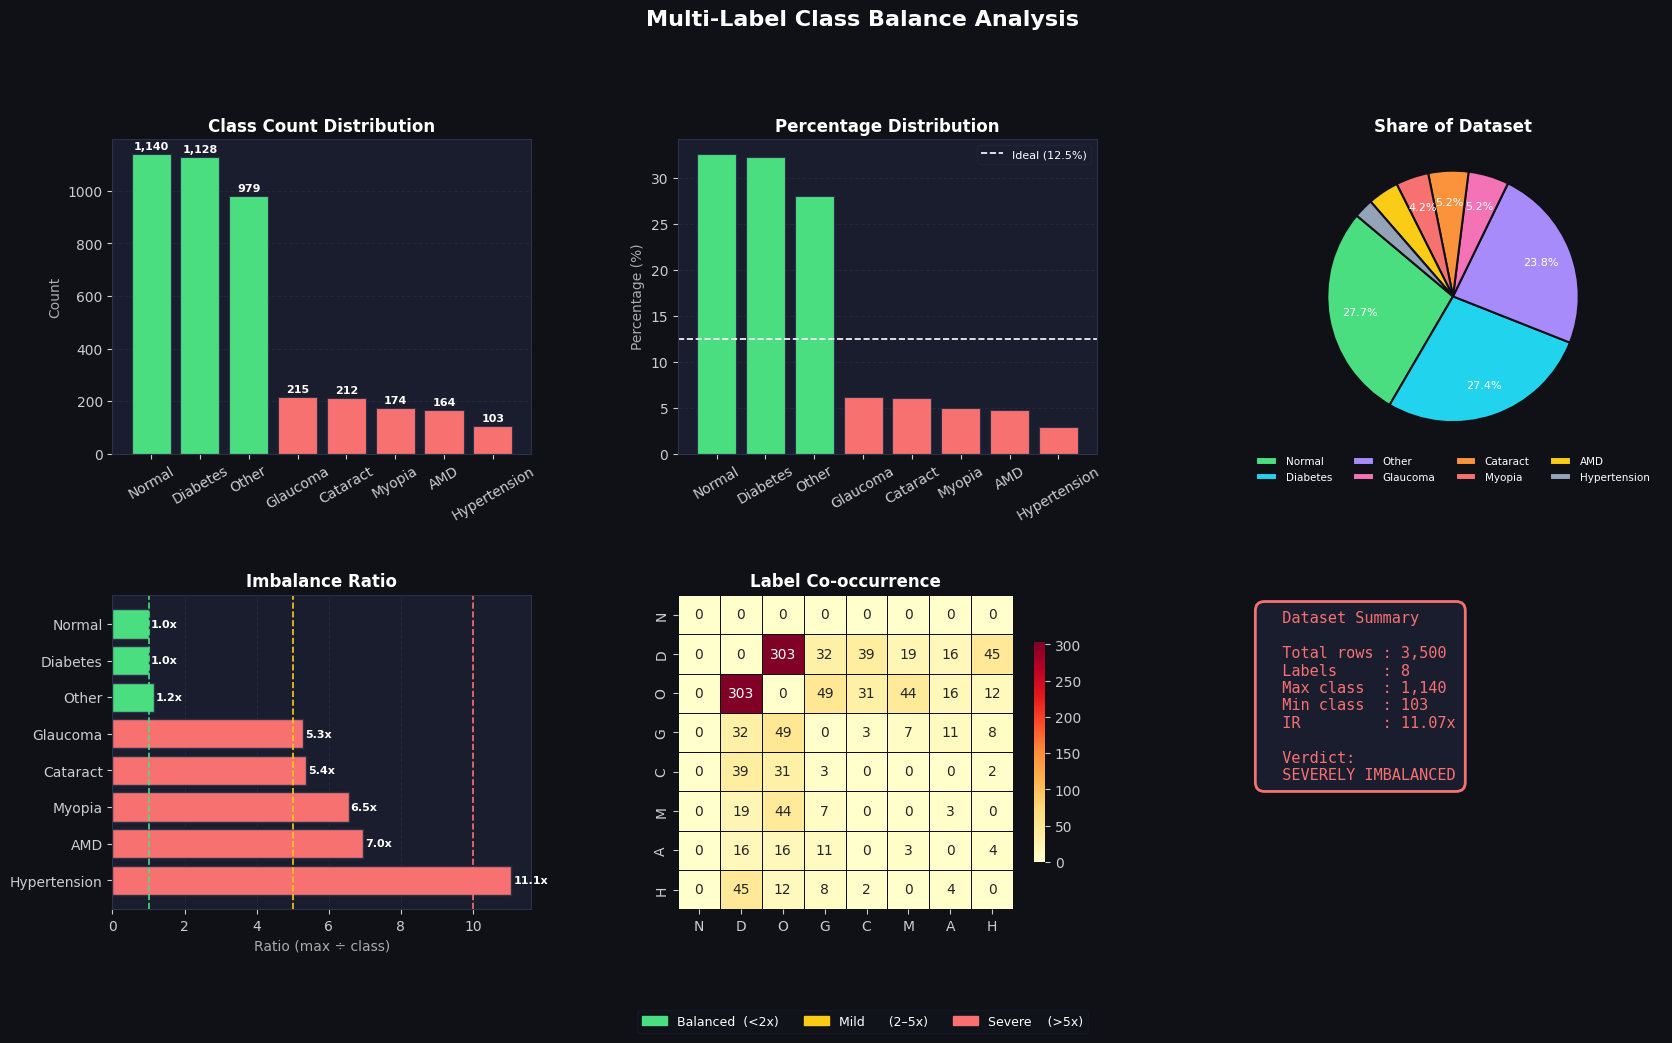

In [20]:
def main():
    df   = load_data(FILE_PATH)
    task, target = detect_task(df, TARGET_COL, MULTI_LABEL_COLS)

    if task == "single":
        stats, total, ir, max_cnt, min_cnt = compute_stats_single(df, target)
        print_report(stats, total, ir, task, max_cnt, min_cnt)
        plot_single(stats, total, ir)
    else:
        stats, total, ir, max_cnt, min_cnt = compute_stats_multi(df, target, LABEL_NAMES)
        print_report(stats, total, ir, task, max_cnt, min_cnt)
        plot_multi(stats, total, ir)


if __name__ == "__main__":
    main()